In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# For na22 Macros  

Will not work anymore, C++ code only works for monoenergetic sources!

Total recorded hits: 91953
            fEnergy
count  91953.000000
mean    1201.524674
std      614.895645
min        0.030290
25%      718.142561
50%     1127.821323
75%     1708.255958
max     2683.776845


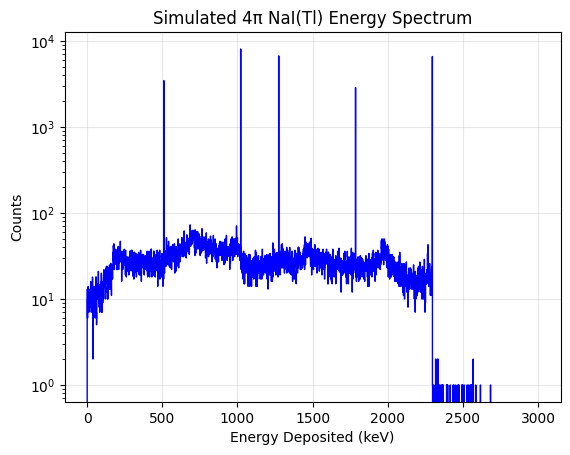

In [13]:
# 1. Open the ROOT file generated by Geant4
file = uproot.open("results/na22_byun.root")

# 2. Extract the Ntuple (Tree) into a pandas DataFrame
# "GammaData" is the name we assigned in run.cc
tree = file["GammaData"]
df = tree.arrays(library="pd")

# 3. Analyze or Plot the DataFrame
print(f"Total recorded hits: {len(df)}")
print(df.describe())

# Plot the spectrum using pandas built-in plotting
df['fEnergy'].plot.hist(bins=3000, range=(0, 3000), histtype='step', color='blue')

plt.title("Simulated 4π NaI(Tl) Energy Spectrum")
plt.xlabel("Energy Deposited (keV)")
plt.ylabel("Counts")
plt.yscale('log') # Log scale helps visualize the Compton continuum and smaller sum peaks
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# List of the specific Sc-44 energy peaks (in keV)
target_peaks = [511, 1022, 1275, 1786, 2297] #for na22
# target_peaks = [511, 1022, 1157, 1668, 2179] #for sc44
# target_peaks = [511, 1022, 2313, 2824, 3335] #for o14

# Define a tiny tolerance window to account for floating-point math
tolerance = 0.51

# Loop through each peak and print the count
for peak in target_peaks:
    # Filter the dataframe for the specific energy window
    peak_data = df[(df['fEnergy'] > peak - tolerance) & (df['fEnergy'] < peak + tolerance)]
    
    # Get the number of rows (counts) that fall in this window
    count = len(peak_data)
    
    print(f"{peak} keV peak count: {count}")

511 keV peak count: 3494
1022 keV peak count: 8118
1275 keV peak count: 6766
1786 keV peak count: 2893
2297 keV peak count: 6621


In [15]:
# 1. Bin the raw data into a mathematical histogram
# Using 3000 bins for a 0-3000 keV range gives us a resolution of 1 keV per bin
counts, bin_edges = np.histogram(df['fEnergy'], bins=3000, range=(0, 3000))

# 2. Calculate the bin centers (bin_edges gives the boundaries, we want the middle)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 3. Find the peaks
# 'height' sets a minimum count threshold to filter out background noise
# 'distance' ensures it doesn't double-count the same peak if it spans multiple bins
peak_indices, properties = find_peaks(counts, height=50, distance=20) 

# 4. Extract the energies and counts for the detected peaks
peak_energies = bin_centers[peak_indices]
peak_counts = counts[peak_indices]

# 5. Display the results
print("Detected Peaks:")
print("-" * 30)
for energy, count in zip(peak_energies, peak_counts):
    print(f"Energy: {energy:.1f} keV  |  Counts: {count}")

Detected Peaks:
------------------------------
Energy: 510.5 keV  |  Counts: 3484
Energy: 605.5 keV  |  Counts: 50
Energy: 645.5 keV  |  Counts: 62
Energy: 685.5 keV  |  Counts: 73
Energy: 718.5 keV  |  Counts: 64
Energy: 741.5 keV  |  Counts: 58
Energy: 763.5 keV  |  Counts: 66
Energy: 792.5 keV  |  Counts: 59
Energy: 839.5 keV  |  Counts: 55
Energy: 926.5 keV  |  Counts: 55
Energy: 964.5 keV  |  Counts: 53
Energy: 993.5 keV  |  Counts: 71
Energy: 1021.5 keV  |  Counts: 8124
Energy: 1274.5 keV  |  Counts: 6759
Energy: 1449.5 keV  |  Counts: 53
Energy: 1489.5 keV  |  Counts: 51
Energy: 1785.5 keV  |  Counts: 2891
Energy: 1977.5 keV  |  Counts: 50
Energy: 2296.5 keV  |  Counts: 6633


In [16]:
# The total number of rows is your total detected count
total_detected_count = len(df)

print(f"Total detected count: {total_detected_count}")

Total detected count: 91953
